#### Libraries

In [1]:
import matplotlib.pyplot as plt
from importlib import import_module
from matplotlib.offsetbox import AnchoredText
from matplotlib.pyplot import cm

from src import datasets, init
from src.algorithms import lloyd

#### Plot configuration

In [2]:
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['lines.markersize'] = 1
plt.rcParams['patch.linewidth'] = .5
plt.rcParams['patch.edgecolor'] = 'gray'
plt.rcParams['patch.force_edgecolor'] = True
plt.rcParams['hatch.color'] = 'gray'
plt.rcParams['hatch.linewidth'] = .5
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 7
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.it'] = 'cm:italic'
plt.rcParams['axes.edgecolor'] = 'gray'
plt.rcParams['axes.linewidth'] = .3
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.titlesize'] = 7
plt.rcParams['axes.axisbelow'] = True
# plt.rcParams['axes.formatter.limits'] = [-2, 6]
plt.rcParams['xtick.major.size'] = plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.width'] = plt.rcParams['ytick.major.width'] = .3
plt.rcParams['xtick.major.pad'] = plt.rcParams['ytick.major.pad'] = 1
plt.rcParams['xtick.color'] = plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.labelsize'] = plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['grid.color'] = 'gainsboro'
plt.rcParams['grid.linewidth'] = .3
plt.rcParams['grid.alpha'] = 1
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.handleheight'] = 1
MM = 1/25.4
plt.rcParams['figure.figsize'] = (150*MM, 30*MM)
plt.rcParams['figure.dpi'] = 1200
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.constrained_layout.hspace'] = 0
plt.rcParams['figure.constrained_layout.wspace'] = .1
plt.rcParams['savefig.dpi'] = 'figure'
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = .01
plt.rcParams['savefig.transparent'] = True

#### Experiment configuration

In [3]:
DATASET_NAME = 'adult'
N_CLUSTERS = 3
RANDOM_STATE = 0
INIT_METHOD = 'kmeans_plusplus'

#### Load dataset

In [4]:
dataset_module = import_module(f"src.datasets.{DATASET_NAME}")
_, X, s, n_nonsensitive = dataset_module.load()

Loading the processed Adult dataset (adult) from 'data/datasets/adult/adult.csv'
╭───────────┬─────────────┬──────────────┬─────────────────────────────┬───────────────────────╮
│   dataset │   # objects │   # features │   # nonsensitive attributes │   sensitive attribute │
├───────────┼─────────────┼──────────────┼─────────────────────────────┼───────────────────────┤
│     adult │       45222 │           25 │                           6 │                   age │
╰───────────┴─────────────┴──────────────┴─────────────────────────────┴───────────────────────╯


#### Initialise cluster centroids

In [5]:
init_method = getattr(import_module("src.init"), INIT_METHOD)
init_centroids = init_method(X=X, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

Initialising centroids using k-means++
  shape: (3, 25)


#### Run Lloyd's heuristic

In [6]:
c, centroids, info, stats = lloyd.run(
    X=X, n_nonsensitive=n_nonsensitive, n_clusters=N_CLUSTERS,
    init_centroids=init_centroids, dataset_name=DATASET_NAME,
    init_method=INIT_METHOD, random_state=RANDOM_STATE
    )

Initiating Lloyd's heuristic
╭───────────┬──────────────┬─────────────────┬────────────────┬─────────────┬────────────┬────────╮
│   dataset │   n_clusters │     init_method │   random_state │   algorithm │   max_iter │    tol │
├───────────┼──────────────┼─────────────────┼────────────────┼─────────────┼────────────┼────────┤
│     adult │            3 │ kmeans_plusplus │              0 │       Lloyd │        100 │ 0.0001 │
╰───────────┴──────────────┴─────────────────┴────────────────┴─────────────┴────────────┴────────╯
Running algorithm
╭────────┬─────────────┬─────────────────┬──────────────────┬──────────────────┬───────────────────┬──────────────────╮
│   iter │   objective │   reassignments │   centroid shift │   centroids time │   assignment time │   iteration time │
├────────┼─────────────┼─────────────────┼──────────────────┼──────────────────┼───────────────────┼──────────────────┤
│      1 │ 7.43080e-01 │           45222 │                - │                - │          263

#### Plot

In [7]:
cluster_sizes = c.value_counts(sort=False)
cluster_pdf = s.groupby(c, sort=False).value_counts(normalize=True, sort=False).sort_index().unstack(level=c.name, fill_value=0)
dataset_pdf = s.value_counts(normalize=True, sort=False).sort_index()
dataset_pdf.name = 'dataset'

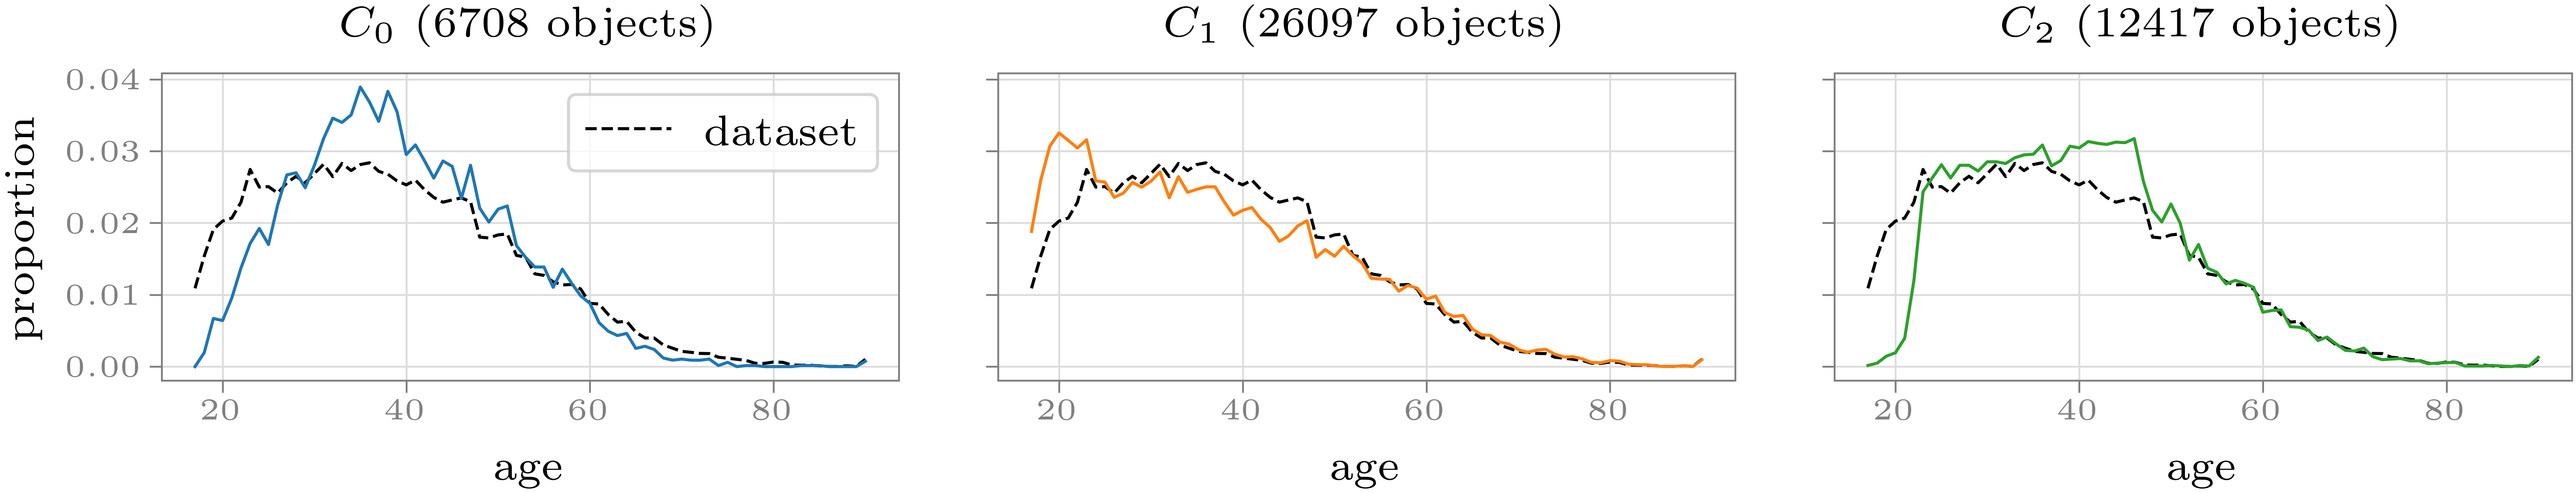

In [8]:
fig, axes = plt.subplots(ncols=N_CLUSTERS, sharex=True, sharey=True)
for i, ax in enumerate(axes):
    ax.title.set_text(f'$C_{i}$ ({cluster_sizes.loc[i]} objects)')
    _ = dataset_pdf.plot.line(color='black', ax=ax, linestyle='--')
    _ = cluster_pdf.loc[:, i].plot.line(color=cm.tab10(i % cm.tab10.N), ax=ax, ylabel='proportion')
handles, labels = axes[0].get_legend_handles_labels()
assert labels[:1][0] == dataset_pdf.name
_ = axes[0].legend(handles[:1], labels[:1], loc='upper right')
fig.savefig(f'data/toy/toy-lloyd k={N_CLUSTERS} r={RANDOM_STATE}.pdf')